In [684]:
import pandas as pd
# Veriyi yükleyelim
df = pd.read_csv("Pfizer4800.csv")
df

,Date,Open,High,Low,Close
0,2005-06-10 00:00:00-04:00,10.893.259,10.910.758,10.657.019,10.783.889
1,2005-07-10 00:00:00-04:00,10.797.012,10.849.509,10.670.142,10.670.142
2,2005-10-10 00:00:00-04:00,10.657.019,10.762.015,10.613.272,10.696.393
3,2005-11-10 00:00:00-04:00,10.696.396,10.727.019,10.512.653,10.630.774
4,2005-12-10 00:00:00-04:00,11.142.626,11.142.626,10.805.766,10.867.013
...,...,...,...,...,...
4795,2024-10-25 00:00:00-04:00,28.680.000,28.730.000,28.440.001,28.450.001
4796,2024-10-28 00:00:00-04:00,28.600.000,28.940.001,28.559.999,28.860.001
4797,2024-10-29 00:00:00-04:00,29.010.000,29.170.000,28.030.001,28.459.999
4798,2024-10-30 00:00:00-04:00,28.309.999,28.600.000,28.190.001,28.520.000


----------

# Veriyi gözden geçirip gerekli düzenlemeleri yapalım.

In [685]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     4800 non-null   object
 1   Open     4800 non-null   object
 2   High     4800 non-null   object
 3   Low      4800 non-null   object
 4   Close    4800 non-null   object
dtypes: object(5)
memory usage: 187.6+ KB


In [686]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close  '], dtype='object')

In [687]:
df.rename(columns={'Close  ': 'Close',}, inplace=True)

In [688]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [689]:
#Önce verilerdeki nokta ile ayrılan sayısal değerleri tek düzeleştirip sonra istediğimiz forma gelecek şekilde yuvarlama işlemine sokacağız.
#Böylece işlem kolayığı sağlanmış olacak.

df['Open'] = df['Open'].astype(str).str.replace('.', '', regex=False)
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
df['High'] = df['High'].astype(str).str.replace('.', '', regex=False)
df['High'] = pd.to_numeric(df['High'], errors='coerce')
df['Low'] = df['Low'].astype(str).str.replace('.', '', regex=False)
df['Low'] = pd.to_numeric(df['Low'], errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace('.', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

In [690]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    4800 non-null   object
 1   Open    4800 non-null   int64 
 2   High    4800 non-null   int64 
 3   Low     4800 non-null   int64 
 4   Close   4800 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 187.6+ KB


In [691]:
df

,Date,Open,High,Low,Close
0,2005-06-10 00:00:00-04:00,10893259,10910758,10657019,10783889
1,2005-07-10 00:00:00-04:00,10797012,10849509,10670142,10670142
2,2005-10-10 00:00:00-04:00,10657019,10762015,10613272,10696393
3,2005-11-10 00:00:00-04:00,10696396,10727019,10512653,10630774
4,2005-12-10 00:00:00-04:00,11142626,11142626,10805766,10867013
...,...,...,...,...,...
4795,2024-10-25 00:00:00-04:00,28680000,28730000,28440001,28450001
4796,2024-10-28 00:00:00-04:00,28600000,28940001,28559999,28860001
4797,2024-10-29 00:00:00-04:00,29010000,29170000,28030001,28459999
4798,2024-10-30 00:00:00-04:00,28309999,28600000,28190001,28520000


In [692]:
# Bir fonksiyon yardımı ile verimizi istediğimiz şekil ve formata dönüştürelim.

def yuvarla_ve_formatla(x):
    if pd.notna(x):  
        x = round(x / 10**6, 2)  
        return f"{x:,.2f}".replace(",", ".")  
    else:
        return x  


sütunlar = ['Open', 'High', 'Low', 'Close']
for sütun in sütunlar:
    
    df[sütun] = df[sütun].apply(yuvarla_ve_formatla)
    df[sütun] = df[sütun].astype(float)

print(df)


                           Date   Open   High    Low  Close
0     2005-06-10 00:00:00-04:00  10.89  10.91  10.66  10.78
1     2005-07-10 00:00:00-04:00  10.80  10.85  10.67  10.67
2     2005-10-10 00:00:00-04:00  10.66  10.76  10.61  10.70
3     2005-11-10 00:00:00-04:00  10.70  10.73  10.51  10.63
4     2005-12-10 00:00:00-04:00  11.14  11.14  10.81  10.87
...                         ...    ...    ...    ...    ...
4795  2024-10-25 00:00:00-04:00  28.68  28.73  28.44  28.45
4796  2024-10-28 00:00:00-04:00  28.60  28.94  28.56  28.86
4797  2024-10-29 00:00:00-04:00  29.01  29.17  28.03  28.46
4798  2024-10-30 00:00:00-04:00  28.31  28.60  28.19  28.52
4799  2024-10-31 00:00:00-04:00  28.45  28.64  28.29  28.30

[4800 rows x 5 columns]


In [693]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4800 non-null   object 
 1   Open    4800 non-null   float64
 2   High    4800 non-null   float64
 3   Low     4800 non-null   float64
 4   Close   4800 non-null   float64
dtypes: float64(4), object(1)
memory usage: 187.6+ KB


-----

## 1. Soru 

Fiyat/Getiri

In [694]:
# hisse fiyatının açılış ve kapanış değerleri arasındaki değişimi, açılış fiyatına oranlayarak yüzde cinsinden getiriyi hesaplama

df['Getiri'] = (df['Close'] - df['Open'])*100/df['Open']
Getiri = df['Getiri'] 
Getiri.head

<bound method NDFrame.head of 0      -1.010101
1      -1.203704
2       0.375235
3      -0.654206
4      -2.423698
          ...   
4795   -0.801953
4796    0.909091
4797   -1.895898
4798    0.741787
4799   -0.527241
Name: Getiri, Length: 4800, dtype: float64>

------
# a)Finansal varlığın temel istatistiklerini bulma

In [695]:
# Temel istatistikler ve diğer hesaplamalar için sütunlar
columns = ['Open', 'High', 'Low', 'Close']

for column in columns:
    # Temel istatistikler
    print(f"{column} Sütunu Temel İstatistikler:")
    print(df[column].describe())
    
    var_value = df[column].var()
    skew_value = df[column].skew()
    kurt_value = df[column].kurt()
    
    print(f"Varyans: {var_value:.2f}")
    print(f"Çarpıklık (Skewness): {skew_value:.2f}")
    print(f"Basıklık (Kurtosis): {kurt_value:.2f}")
    print("\n" + "-"*50 + "\n")  

Open Sütunu Temel İstatistikler:
count    4800.000000
mean       21.616246
std        10.631120
min         6.180000
25%        11.580000
50%        20.965000
75%        29.062500
max        53.730000
Name: Open, dtype: float64
Varyans: 113.02
Çarpıklık (Skewness): 0.58
Basıklık (Kurtosis): -0.44

--------------------------------------------------

High Sütunu Temel İstatistikler:
count    4800.000000
mean       21.818598
std        10.749870
min         6.350000
25%        11.680000
50%        21.215000
75%        29.285000
max        54.720000
Name: High, dtype: float64
Varyans: 115.56
Çarpıklık (Skewness): 0.60
Basıklık (Kurtosis): -0.40

--------------------------------------------------

Low Sütunu Temel İstatistikler:
count    4800.000000
mean       21.411629
std        10.511993
min         6.060000
25%        11.490000
50%        20.730000
75%        28.780000
max        53.050000
Name: Low, dtype: float64
Varyans: 110.50
Çarpıklık (Skewness): 0.57
Basıklık (Kurtosis): -0.46

-

Yorumlar:

Open Sütunu:
Ortalama (Mean): 21.62, bu değerin fiyatın ortalama seviyesini gösterir. Bu, fiyatın genellikle bu seviyelerde işlem gördüğünü ifade eder.
Standart Sapma (Std): 10.63,  Standart sapma görece yüksek bu durum dalgalanmayı ifade eder.
Varyans: 113.02, fiyatların değişken olduğunu gösteriyor.
Çarpıklık katsayısı : 0.58, pozitif bir çarpıklık olduğu için fiyat dağılımı sağa kaymış ve genellikle daha yüksek değerler oluşmuş. Ancak bu değer çok büyük değil, bu da fiyatların genellikle simetrik dağıldığını gösterir.
Basıklık kaysayısı (: -0.44, negatif bir basıklık değeri, dağılmanın düz ve geniş olduğunu, yani uç değerlerin çok fazla olmadığını işaret eder.

High Sütunu:
Ortalama (Mean): 21.82, "High" fiyatı biraz daha yüksek olduğu için fiyatlar genellikle 21.82 civarında işlem görmüş.
Standart Sapma (Std): 10.75, "Open" ile benzer bir dalgalanma seviyesi.
Çeyrek Dilimler (25%, 50%, 75%): Dağılımın sağa kaymış olduğunu gösterebilir; yüksek fiyatlar daha yaygın.
Varyans: 115.56, Open fiyatına oldukça yakın bir değer.
Çarpıklık kaysayısı: 0.60, "High" fiyatları da sağa kaymış, ancak Open'a göre biraz daha fazla kayma var.
Basıklık kaysayısı: -0.40, yine uç değerlerin çok fazla olmadığını, ancak dağılımın oldukça yaygın olduğunu gösteriyor.

Low Sütunu:
Ortalama (Mean): 21.41, düşük fiyatlar genellikle 21.41 seviyelerinde işlem görmüş.
Standart Sapma (Std): 10.51, yine yüksek volatiliteyi işaret eder, fakat diğer sütunlarla benzer.
Çeyrek Dilimler (25%, 50%, 75%): Çeyrek dilimler birbirine oldukça yakın; yani düşük fiyatlar dağılma yönü açısından çok fazla sapmıyor.
Varyans: 110.50, "Open" fiyatına göre biraz daha düşük, ama yine de yüksek volatiliteyi işaret eder.
Çarpıklık kaysayısı: 0.57, yine sağa kaymış bir dağılım gösteriyor, ancak bir miktar daha simetrik.
Basıklık kaysayısı: -0.46, düz ve geniş bir dağılım, uç değerler çok fazla değil.

Close Sütunu:
Ortalama (Mean): 21.62, "Close" fiyatı da "Open" ile neredeyse aynı seviyede. Bu da fiyatların genellikle açılış ve kapanış arasında çok fazla sapma göstermediğini gösterebilir.
Standart Sapma (Std): 10.63, aynı şekilde volatilite biraz yüksek.
Varyans: 113.08, "Open" ile çok benzer.
Çarpıklık kaysayısı: 0.59, sağa kaymış bir dağılım.
Basıklık kaysayısı: -0.43, oldukça yaygın bir dağılım, uç değerler pek fazla değil.

Genel Yorum:
Fiyatlar genellikle simetrik olmayan, ama uç değerlerin çok da yaygın olmadığı bir dağılım gösteriyor.
Çarpıklık her dört sütunda da pozitif, yani fiyatların çoğunluğu ortalamanın biraz altında kalmış, ancak bazı yüksek değerler daha az sıklıkta olmak üzere mevcuttur. Basıklık negatif olduğu için, dağılımlar genellikle geniş ve düz. Yani uç değerler, çok yaygın olmayan büyük fiyat hareketleri, fazla gözlemlenmiyor.

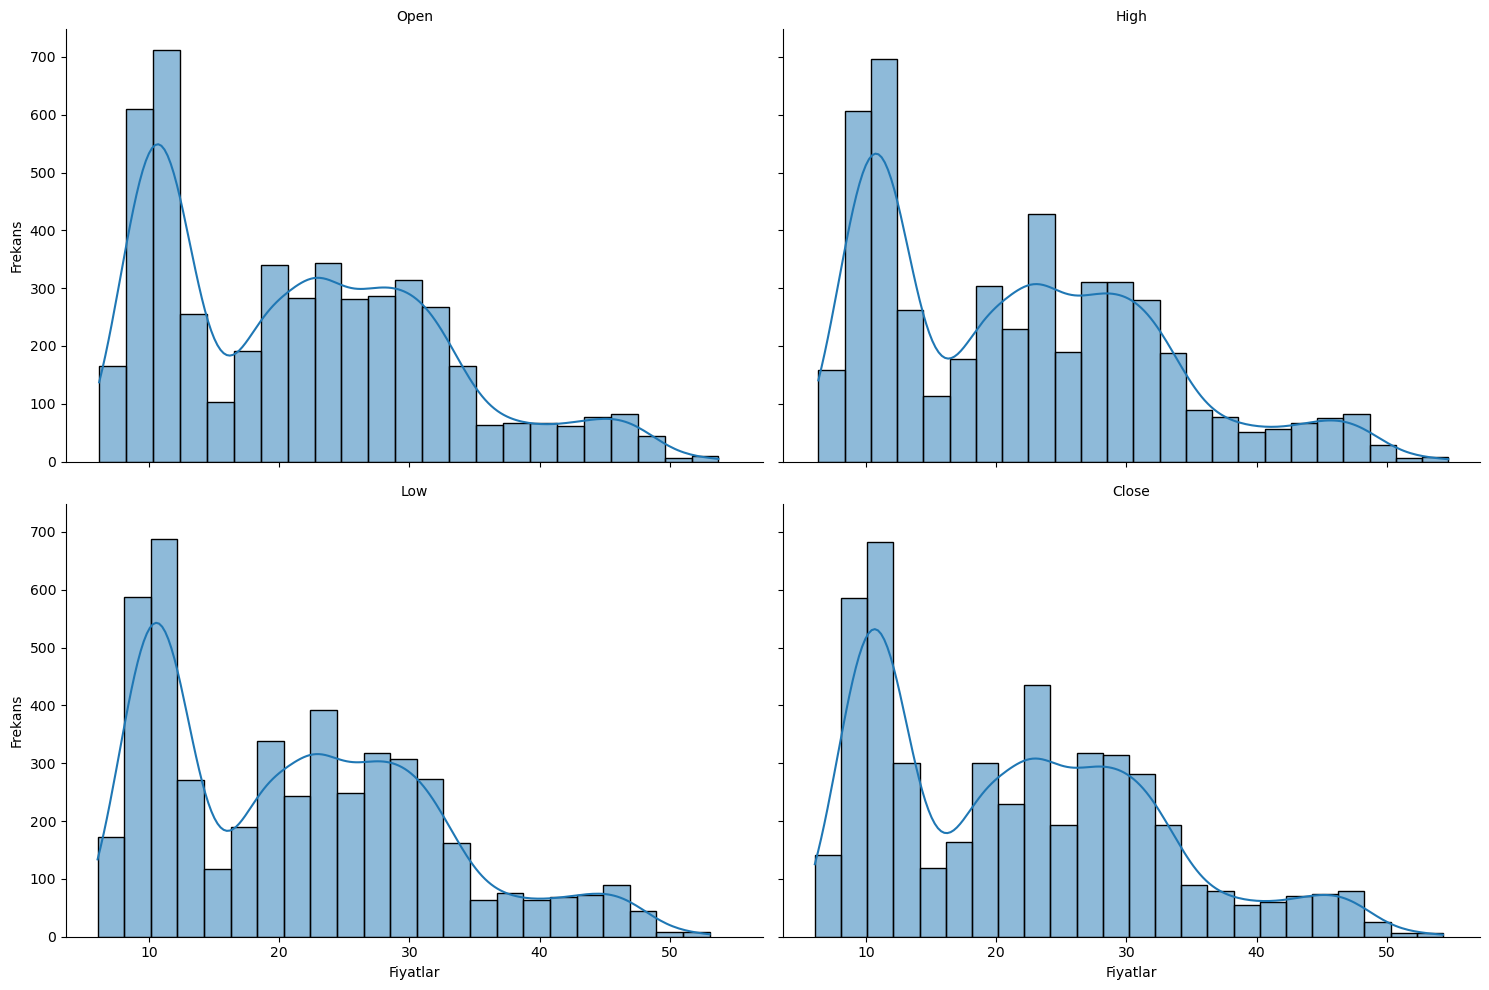

In [696]:
# Grafikler için ihtiyacımız olacak kütüphaneleri çağırarak başlayalım

import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import numpy as np

df_melted = df[columns].melt(var_name="variable", value_name="value")
g = sns.FacetGrid(df_melted, col="variable", col_wrap=2, height=5, aspect=1.5)
g.map(sns.histplot, "value", kde=True)
g.set_axis_labels('Fiyatlar', 'Frekans')
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()


Yorum:Grafikler genel olarak fiyatların büyük çoğunlukla 10-20 dolar aralığında olduğunu gösteriyor, özellikle açılış ve kapanış fiyatlarında bu durumu net bir şekilde görebiliyoruz.Fiyatlar zaman zaman daha yüksek seviyelere çıksa da (özellikle 20-30 dolar aralığı), bu nadiren gerçekleşiyor.Çift tepe eğrisi hem yüksek hem de kapanış fiyatlarında belirgin durumda. Buradan, belirli dönemlerde fiyatlarda dalgalanmalar ve yüksek fiyatlara sıçramalar yaşandığını söyleyebiliriz.Frekansa bakacak olursak fiyatlar genellikle düşük seviyelerde sabit kalmış, ancak belirli zamanlarda fiyat hareketliliği yaşanmış.Bu grafikler, finansal varlığın fiyat dinamiklerini anlamak için faydalı. Özellikle yatırım stratejisi belirlerken, bu fiyat aralıklarını ve nadir de olsa görülen yüksek fiyatları dikkate almak önemli olabilir.

---------
# b)Zamana bağlı getiri hareketi grafiği.

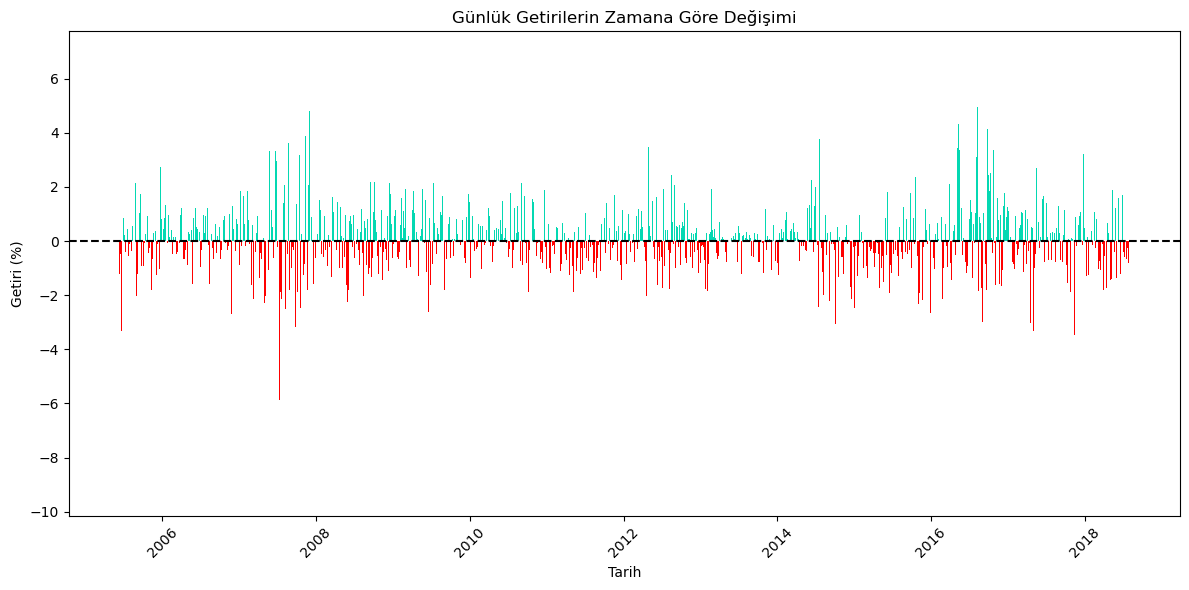

In [697]:
# Pfeizer hisse senedi getirilerinin zamana bağlı dağılımını gösteren çubuk grafiği

import matplotlib.colors as mcolors
import matplotlib.patches as mpatch

tarih = pd.date_range(start='2005-06-10', periods=4800, freq='D')
center_line = 0

# Üstte ve altta kalan çubukları farklı renklerle renklendirerek anlaşılırlığını arttırabiliriz

colors = ['#04D8B2' if value >= center_line else 'red' for value in Getiri]

# Çubuk Grafiği (Bar Chart) - Tarihe göre Getiriler
plt.figure(figsize=(12, 6))  
plt.bar(tarih, Getiri, color=colors)
plt.axhline(y=center_line, color='black', linewidth=1.5, linestyle='--', label='Orta Çizgi (0)')

plt.title('Günlük Getirilerin Zamana Göre Değişimi')
plt.xlabel('Tarih')
plt.ylabel('Getiri (%)')

plt.xticks(rotation=45)  
plt.tight_layout()  
plt.show()


------
# c)Blok Maksima ile fiyat/getirisi için uygun uç değer dağılımları.

In [698]:
df.keys()

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Getiri'], dtype='object')

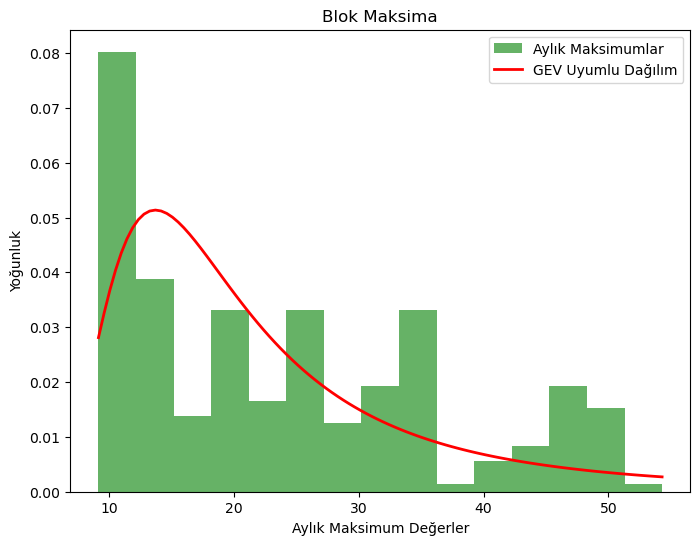

Kolmogorov-Smirnov Testi: KS İstatistiği = 0.14487775289535268, P-değeri = 7.358212424652453e-05
2 yıllık geri dönüş seviyesi: 19.25
5 yıllık geri dönüş seviyesi: 32.26
10 yıllık geri dönüş seviyesi: 44.92


In [699]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
from scipy.stats import kstest

df['Date'] = pd.to_datetime(df['Date'], utc=True)  

# 'Date' sütununu indeks yapıyoruz
df.set_index('Date', inplace=True)  

# Aylık maksimum değerler
monthly_max = df['Close'].resample('M').max() 

# GEV dağılımı
gev_params = gev.fit(monthly_max.dropna())  

# GEV parametreleri ile modelin grafiği
x = np.linspace(monthly_max.min(), monthly_max.max(), 100)
pdf = gev.pdf(x, *gev_params)  # GEV olasılık yoğunluk fonksiyonu

plt.figure(figsize=(8, 6))
plt.hist(monthly_max, bins=15, density=True, alpha=0.6, color='g', label='Aylık Maksimumlar')
plt.plot(x, pdf, 'r-', lw=2, label='GEV Uyumlu Dağılım')
plt.title('Blok Maksima')
plt.xlabel('Aylık Maksimum Değerler')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()

# Kolmogorov-Smirnov testi 
ks_stat, p_value = kstest(monthly_max.dropna(), 'genextreme', args=gev_params)
print(f"Kolmogorov-Smirnov Testi: KS İstatistiği = {ks_stat}, P-değeri = {p_value}")

# 2, 5, 10 yıllık geri dönüş seviyeleri
return_periods = [2, 5, 10]
return_levels = gev.isf(1/np.array(return_periods), *gev_params)
for rp, rl in zip(return_periods, return_levels):
    print(f"{rp} yıllık geri dönüş seviyesi: {rl:.2f}")
    
df_reset = df.reset_index()  


In [700]:
df

,Open,High,Low,Close,Getiri
Date,,,,,
2005-06-10 04:00:00+00:00,10.89,10.91,10.66,10.78,-1.010101
2005-07-10 04:00:00+00:00,10.80,10.85,10.67,10.67,-1.203704
2005-10-10 04:00:00+00:00,10.66,10.76,10.61,10.70,0.375235
2005-11-10 04:00:00+00:00,10.70,10.73,10.51,10.63,-0.654206
2005-12-10 04:00:00+00:00,11.14,11.14,10.81,10.87,-2.423698
...,...,...,...,...,...
2024-10-25 04:00:00+00:00,28.68,28.73,28.44,28.45,-0.801953
2024-10-28 04:00:00+00:00,28.60,28.94,28.56,28.86,0.909091
2024-10-29 04:00:00+00:00,29.01,29.17,28.03,28.46,-1.895898


Yukarıda görülüyor ki bir önceki işlemde verimiz değişime uğramış ve tarih sütunu artık bir anahtar olarak görünmüyor.
Bu durumu tekrar düzeltip işleme devam etmeliyiz.

In [701]:
# 'Date' sütununu tekrar veri çerçevesine alıyoruz
df['Date'] = df.index
df.set_index('Date', inplace=True)
print(df.head())



                            Open   High    Low  Close    Getiri
Date                                                           
2005-06-10 04:00:00+00:00  10.89  10.91  10.66  10.78 -1.010101
2005-07-10 04:00:00+00:00  10.80  10.85  10.67  10.67 -1.203704
2005-10-10 04:00:00+00:00  10.66  10.76  10.61  10.70  0.375235
2005-11-10 04:00:00+00:00  10.70  10.73  10.51  10.63 -0.654206
2005-12-10 04:00:00+00:00  11.14  11.14  10.81  10.87 -2.423698


In [702]:
df['Date'] = df.index
df = df[['Date'] + [col for col in df.columns if col != 'Date']]

# Şimdi 'Date' anahtar olarak kullanılabilir
print(df.head())

                                               Date   Open   High    Low  \
Date                                                                       
2005-06-10 04:00:00+00:00 2005-06-10 04:00:00+00:00  10.89  10.91  10.66   
2005-07-10 04:00:00+00:00 2005-07-10 04:00:00+00:00  10.80  10.85  10.67   
2005-10-10 04:00:00+00:00 2005-10-10 04:00:00+00:00  10.66  10.76  10.61   
2005-11-10 04:00:00+00:00 2005-11-10 04:00:00+00:00  10.70  10.73  10.51   
2005-12-10 04:00:00+00:00 2005-12-10 04:00:00+00:00  11.14  11.14  10.81   

                           Close    Getiri  
Date                                        
2005-06-10 04:00:00+00:00  10.78 -1.010101  
2005-07-10 04:00:00+00:00  10.67 -1.203704  
2005-10-10 04:00:00+00:00  10.70  0.375235  
2005-11-10 04:00:00+00:00  10.63 -0.654206  
2005-12-10 04:00:00+00:00  10.87 -2.423698  


In [703]:
df.keys()

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Getiri'], dtype='object')

-----------------------
# 2.Soru

Portföy oluşturmak için ikinci varlığın tanımlanması

In [704]:
df1 = pd.read_csv("WarnerBros4800.csv")
df1

,Date,Open,High,Low,Close
0,2005-10-06 00:00:00-04:00,7.082269,7.153807,7.020950,7.056719
1,2005-10-07 00:00:00-04:00,7.036280,7.153807,7.036280,7.143587
2,2005-10-10 00:00:00-04:00,7.112928,7.230455,7.102708,7.138477
3,2005-10-11 00:00:00-04:00,7.128258,7.230455,7.102708,7.179356
4,2005-10-12 00:00:00-04:00,7.138477,7.189576,7.128258,7.164027
...,...,...,...,...,...
4795,2024-10-25 00:00:00-04:00,7.590000,7.790000,7.550000,7.600000
4796,2024-10-28 00:00:00-04:00,7.680000,7.770000,7.580000,7.610000
4797,2024-10-29 00:00:00-04:00,7.530000,7.710000,7.490000,7.550000
4798,2024-10-30 00:00:00-04:00,7.520000,7.840000,7.500000,7.770000


In [705]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4800 non-null   object 
 1   Open    4800 non-null   float64
 2   High    4800 non-null   float64
 3   Low     4800 non-null   float64
 4   Close   4800 non-null   float64
dtypes: float64(4), object(1)
memory usage: 187.6+ KB


In [706]:
#Veriyi düzenleme

# 'Date' sütununu datetime formatına çevirirken UTC zaman dilimine çevirip index atıyoruz.
df1['Date'] = pd.to_datetime(df1['Date'], utc=True)
df1.set_index('Date', inplace=True)
print(df1.info())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4800 entries, 2005-10-06 04:00:00+00:00 to 2024-10-31 04:00:00+00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    4800 non-null   float64
 1   High    4800 non-null   float64
 2   Low     4800 non-null   float64
 3   Close   4800 non-null   float64
dtypes: float64(4)
memory usage: 187.5 KB
None


In [707]:
df1.keys()

Index(['Open', 'High', 'Low', 'Close'], dtype='object')

In [708]:
df.keys()

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Getiri'], dtype='object')

In [709]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4800 entries, 2005-06-10 04:00:00+00:00 to 2024-10-31 04:00:00+00:00
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Date    4800 non-null   datetime64[ns, UTC]
 1   Open    4800 non-null   float64            
 2   High    4800 non-null   float64            
 3   Low     4800 non-null   float64            
 4   Close   4800 non-null   float64            
 5   Getiri  4800 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(5)
memory usage: 262.5 KB




İki veri kümesinin de eşlenebildiğinden emin olduk artık işleme başlayabiliriz.

-------------

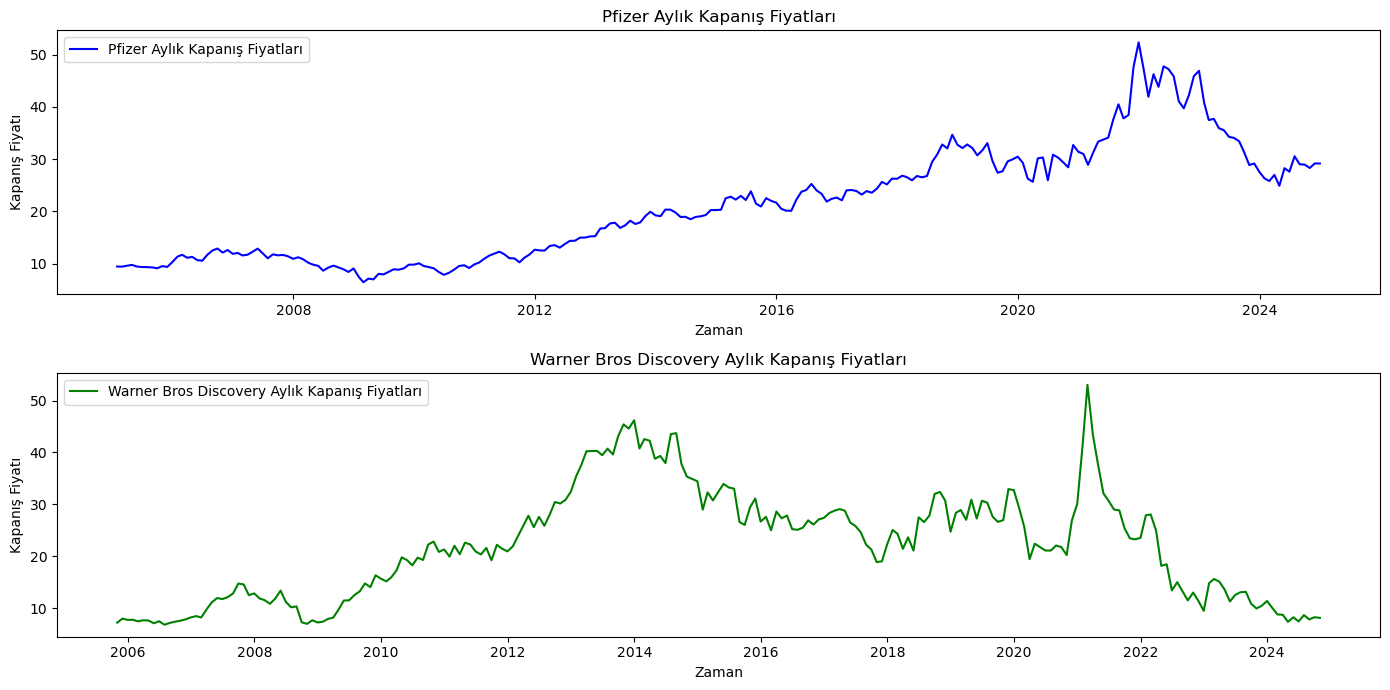

Portföy Ortalama Getirisi: 0.0065
Portföy Volatilitesi: 0.0667
İki Varlık Arasındaki Korelasyon: 0.1459

Pfizer Aylık Kapanış Fiyatları İstatistikleri:
count    240.000000
mean      21.211583
std       10.675053
min        6.420000
25%       11.317500
50%       20.270000
75%       29.047500
max       52.360000
Name: Close, dtype: float64

Warner Bros Discovery Aylık Kapanış Fiyatları İstatistikleri:
count    229.000000
mean      22.089657
std       10.498587
min        6.806336
25%       12.498723
50%       22.207460
75%       28.780001
max       53.029999
Name: Close, dtype: float64


In [710]:
import pandas as pd
import matplotlib.pyplot as plt

df.index = pd.to_datetime(df.index).tz_localize(None)
df1.index = pd.to_datetime(df1.index).tz_localize(None)

# Aylık kapanış fiyatlarını alıyoruz
df_monthly = df['Close'].resample('M').last()
df1_monthly = df1['Close'].resample('M').last()

# Grafikler
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(df_monthly, label="Pfizer Aylık Kapanış Fiyatları", color='blue')
plt.title("Pfizer Aylık Kapanış Fiyatları")
plt.xlabel("Zaman")
plt.ylabel("Kapanış Fiyatı")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df1_monthly, label="Warner Bros Discovery Aylık Kapanış Fiyatları", color='green')
plt.title("Warner Bros Discovery Aylık Kapanış Fiyatları")
plt.xlabel("Zaman")
plt.ylabel("Kapanış Fiyatı")
plt.legend()

plt.tight_layout()
plt.show()

# Portföy ağırlıkları (eşit ağırlık)
weight_pfizer = 0.5
weight_wb = 0.5

# Portföy getirileri
pfizer_returns = df_monthly.pct_change().dropna()
wb_discovery_returns = df1_monthly.pct_change().dropna()
portfoy_returns = weight_pfizer * pfizer_returns + weight_wb * wb_discovery_returns

# Portföy ortalaması ve volatilitesi
portfoy_mean = portfoy_returns.mean()
portfoy_volatility = portfoy_returns.std()
print(f"Portföy Ortalama Getirisi: {portfoy_mean:.4f}")
print(f"Portföy Volatilitesi: {portfoy_volatility:.4f}")

# Korelasyon hesaplama
korelasyon = pfizer_returns.corr(wb_discovery_returns)
print(f"İki Varlık Arasındaki Korelasyon: {korelasyon:.4f}")

# Tanımlayıcı İstatistikler
print("\nPfizer Aylık Kapanış Fiyatları İstatistikleri:")
print(df_monthly.describe())

print("\nWarner Bros Discovery Aylık Kapanış Fiyatları İstatistikleri:")
print(df1_monthly.describe())


-------

# a)Bu değerlere göre tek bir finansal varlığa yatırım veya portföy oluşturmanın hangisinin daha karlı olduğuna yatırımcı açısından karar veriniz.
Cevap: Her bir varlığı tek tek ve portföyü de ayrı olarak değerlendirelim sonrasında bu bilgilerden kıyaslamaya geçebiliriz.
Pfizer:
Ortalama Getiri: Pfizer’in ortalama aylık kapanış fiyatı 21.21'dir. Kapanış fiyatlarındaki artış, uzun vadede büyüme potansiyeli gösteriyor. En yüksek değeri 52.36 ile maksimum noktada gözüküyor.

Warner Bros Discovery:
Ortalama Getiri: Warner Bros’un ortalama kapanış fiyatı 22.08'dir. Bunun yanında maksimum değeri 53.02, Pfizer'e çok benzer bir noktadadır. Fakat Warner Bros’un fiyat volatilitesi daha yüksek gözüküyor (std: 10.49).

Portföy:
Portföyün ortalama getirisi 0.0065, volatilitesi ise 0.0667'dir. Bu, iki varlık arasında ağırlıkları eşit paylaştırarak riskin dağıtılmasıyla oluşturulmuştur.

Yatırımcı Açısından Karar:
Portföy oluşturmanın amacı genellikle riski azaltmak ve getiriyi stabilize etmek olduğu düşünülünce. Bu portföy, her iki varlığa da yatırım yaparak, volatiliteyi düşürmeye çalışıyor. Yani iki varlığın fiyat hareketlerinin dengelenmesi, daha stabil bir getiri sağlama potansiyeli taşıyor.Tek bir varlıkla yatırım yapıldığında ise, Pfizer veya Warner Bros Discovery’nin volatilitesinden etkilenme ihtimali daha yüksek. Özellikle Warner Bros Discovery'nin daha volatil olduğunu görüyoruz, bu da riski artırabilir.

Sonuç olarak eğer yatırımcı daha az risk ve daha stabil getiri istiyorsa, portföy (0.5, 0.5) dağılımıyla yatırım daha mantıklı olacaktır.
Eğer yatırımcı yüksek risk ile birlikte daha fazla potansiyel kâr arayışındaysa, bireysel varlıklara yatırım (özellikle Warner Bros Discovery, daha fazla volatilite ve fırsat sunduğu için) düşünülebilir.


-------------

# b)Portföyü oluşturan iki finansal varlığın arasındaki ilişkiyi korelasyon katsayısı değerine dayanarak inceleyiniz ve yorumlayınız.

Cevap: Portföye mi yoksa tek bir varlığa mı yatıtım yapılmasının uygun olduğunu anlamak için karşılaştırma yapalım:
Portföy Ortalama Getirisi: 0.0065, Portföy Volatilitesi: 0.0667, İki Varlık Arasındaki Korelasyon: 0.1459

Portföy oluşturmanın avantajı, iki varlık arasında düşük korelasyon olduğundan riski azaltabilir. Korelasyonun düşük olması, varlıkların fiyatlarının aynı yönde hareket etme olasılığının düşük olduğunu gösterir. Bu da riskin daha dengeli dağıldığı anlamına gelir.

Sonuç olarak portföy, yatırımcı açısından daha düşük bir risk seviyesine sahip olabilir. Varlıklar arasındaki düşük korelasyon ve volatilitenin yönetilebilir düzeyde olması, portföy yatırımı yapmanın tek bir varlığa yatırım yapmaktan daha karlı ve güvenli olabileceğini gösterir. Yani, portföy oluşturmak, iki varlık arasındaki düşük korelasyon sayesinde riski azaltarak uzun vadede daha güvenli bir yatırım seçeneği olabilir. Ancak, getiriyi maksimize etmek isteyen yatırımcılar için tek bir varlığa yatırım yaparak daha yüksek risk-alma potansiyeli de düşünülebilecek bir seçenek diyebiliriz.




